--Northwind ERP Supply Chain Analysis--

Insights:
## Order Fulfillment
-Average fulfillment time is 7.4 days across all 16,261 orders
-Std deviation is very high at 6.8 days, indicating grave inconsistency in supply chain performance, with the longest shipment time at 37 days
-Median of 5 days is lower than the mean of 7.4, indicating that a few very slow orders are dragging the average up, making actual performance harder to discern
-Enormous variance between the min and max shipping times, 0 and 37 days respectively, hinting at an ineffectively standardized fulfillment process

## Late Shipments
-23% of orders were late, a rate of nearly 1 in 4
-This is 18% over the upper end of the commonly accepted industry benchmark

## Revenue by Product
-Beverages dominate at 92M, nearly 40% more than the second place, Confections, at 66M
-Grains/Cereals is the least profitable category, at 28M, suggesting either low demand, poor sales, or high manufacturing costs
-The wide spread between the best and worst performing categories suggests a skew in inventory investment benefitting the top categories

## Top 10 Customers
-B's Beverages leads at 6.15M, notably a beverage company buying from the most profitable product category
-The top 10 customers are tightly grouped with only a 700k gap between first and tenth place
-No single customer dominates, indicating a healthy  customer diversification of and low concentration risk

## Linear Regression - Order Value vs Quantity
-R2 of 0.15 means quantity only explains 15% of order value
-Each additional unit ordered add $28.85 in value on average
-Pricing strategy is driving revenue more than volume, the scatter plot reveals distinct pricing tiers for each product, meaning what product is bought matters more than how much of it

Dataset: Nrothwind SQLite3, a normalized relational database modeled after real ERP schemas (SAP/Oracle)
Modeled by: John Haiges 

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("northwind (2).db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


In [2]:
orders = pd.read_sql("SELECT * FROM Orders LIMIT 5", conn)
orders.head()

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2016-07-04,2016-08-01,2016-07-16,3,16.75,Vins et alcools Chevalier,59 rue de l-Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2016-07-08,2016-08-05,2016-07-12,2,25.00,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2016-07-08,2016-08-05,2016-07-15,1,20.25,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2016-07-09,2016-08-06,2016-07-11,2,36.25,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium


In [9]:
orders = pd.read_sql("SELECT OrderID, OrderDate, ShippedDate, RequiredDate FROM Orders", conn)

orders['OrderDate'] = pd.to_datetime(orders['OrderDate'], format='mixed')
orders['ShippedDate'] = pd.to_datetime(orders['ShippedDate'], format='mixed')

orders['FulfillmentDays'] = (orders['ShippedDate'] - orders['OrderDate']).dt.days

print(orders['FulfillmentDays'].describe())

count    16261.000000
mean         7.363569
std          6.785542
min          0.000000
25%          2.000000
50%          5.000000
75%         11.000000
max         37.000000
Name: FulfillmentDays, dtype: float64


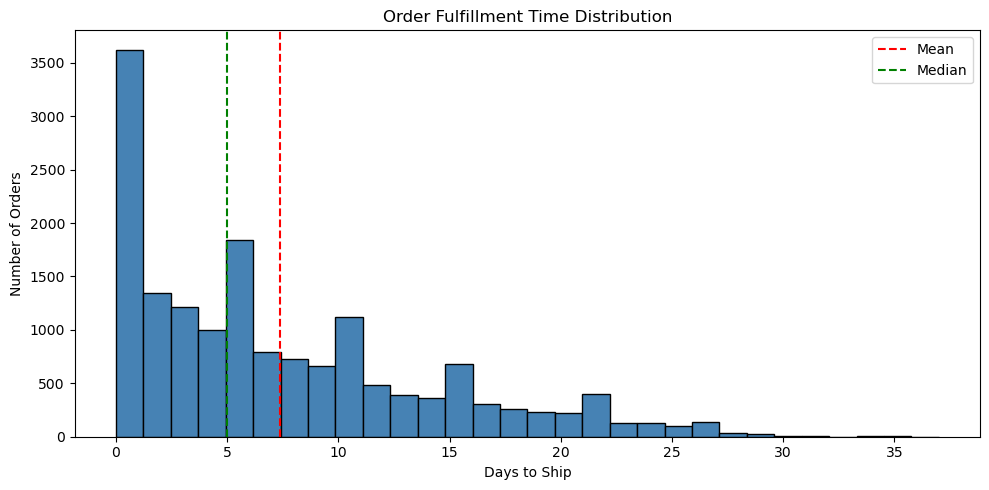

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(orders['FulfillmentDays'].dropna(), bins=30, color='steelblue', edgecolor='black')

plt.title('Order Fulfillment Time Distribution')
plt.xlabel('Days to Ship')
plt.ylabel('Number of Orders')

mean_val = orders['FulfillmentDays'].mean()
median_val = orders['FulfillmentDays'].median()

plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='--', label='Median')

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
orders['RequiredDate'] = pd.to_datetime(orders['RequiredDate'], format='mixed')

orders['IsLate'] = orders['ShippedDate'] > orders['RequiredDate']

late_rate = orders['IsLate'].sum() / orders['IsLate'].count() * 100

print(f"Total orders: {orders['IsLate'].count()}")
print(f"Late orders: {orders['IsLate'].sum()}")
print(f"Late shipment rate: {late_rate:.2f}%")

Total orders: 16282
Late orders: 3755
Late shipment rate: 23.06%


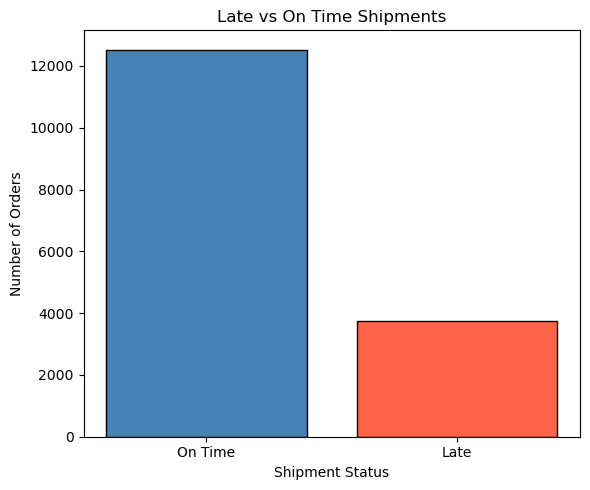

In [16]:
late_counts = orders['IsLate'].value_counts()

late_counts.index = ['On Time', 'Late']

plt.figure(figsize=(6, 5))
plt.bar(late_counts.index, late_counts.values, color=['steelblue','tomato'], edgecolor='black')
plt.title('Late vs On Time Shipments')
plt.xlabel('Shipment Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [18]:
revenue_by_category = pd.read_sql("""
    SELECT 
        c.CategoryName,
        ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS TotalRevenue
    FROM [Order Details] od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories c ON p.CategoryID = c.CategoryID
    GROUP BY c.CategoryName
    ORDER BY TotalRevenue DESC
""", conn)
print(revenue_by_category)

     CategoryName  TotalRevenue
0       Beverages   92163184.18
1     Confections   66337803.06
2    Meat/Poultry   64881147.97
3  Dairy Products   58018116.78
4      Condiments   55795126.78
5         Seafood   49921604.17
6         Produce   32701119.88
7  Grains/Cereals   28568530.34


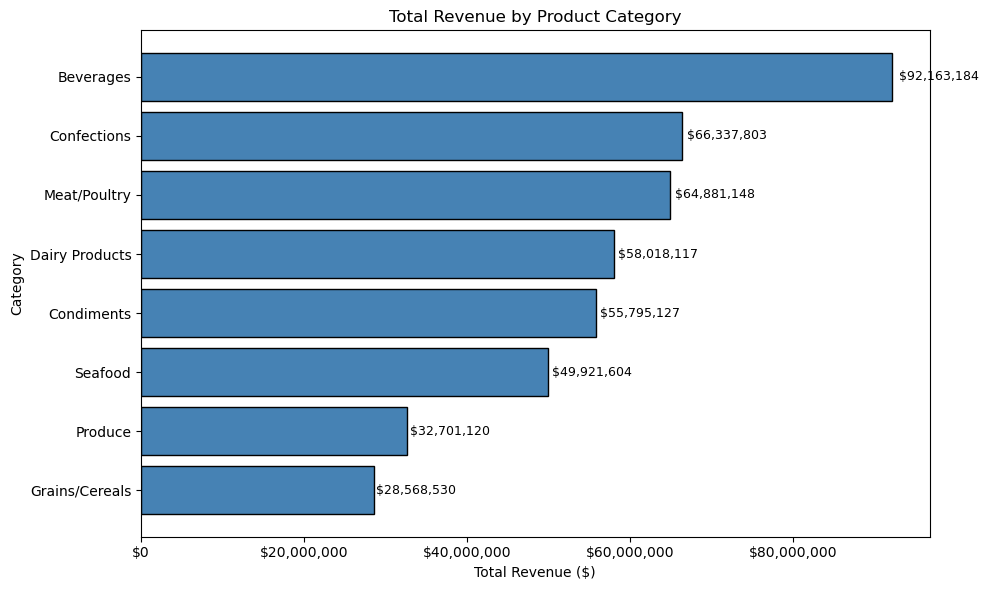

In [27]:
import matplotlib.ticker as mticker

revenue_by_category['TotalRevenue'] = revenue_by_category['TotalRevenue'].round(0).astype(int)

plt.figure(figsize=(10, 6))
bars = plt.barh(revenue_by_category['CategoryName'], 
                revenue_by_category['TotalRevenue'], 
                color='steelblue', edgecolor='black')
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
             f'${int(width):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
top_customers = pd.read_sql("""
    SELECT 
        c.CustomerID,
        c.CompanyName,
        ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 0) AS TotalRevenue
    FROM Customers c
    JOIN Orders o ON c.CustomerID = o.CustomerID
    JOIN [Order Details] od ON o.OrderID = od.OrderID
    GROUP BY c.CustomerID, c.CompanyName
    ORDER BY TotalRevenue DESC
    LIMIT 10
""", conn)

print(top_customers)

  CustomerID                         CompanyName  TotalRevenue
0      BSBEV                       B's Beverages     6154115.0
1      HUNGC          Hungry Coyote Import Store     5698024.0
2      RANCH                       Rancho grande     5559110.0
3      GOURL                 Gourmet Lanchonetes     5552310.0
4      ANATR  Ana Trujillo Emparedados y helados     5534357.0
5      RICAR                  Ricardo Adocicados     5524517.0
6      FOLIG                   Folies gourmandes     5505503.0
7      LETSS                   Let's Stop N Shop     5462198.0
8      LILAS                   LILA-Supermercado     5437438.0
9      PRINI              Princesa Isabel Vinhos     5436771.0


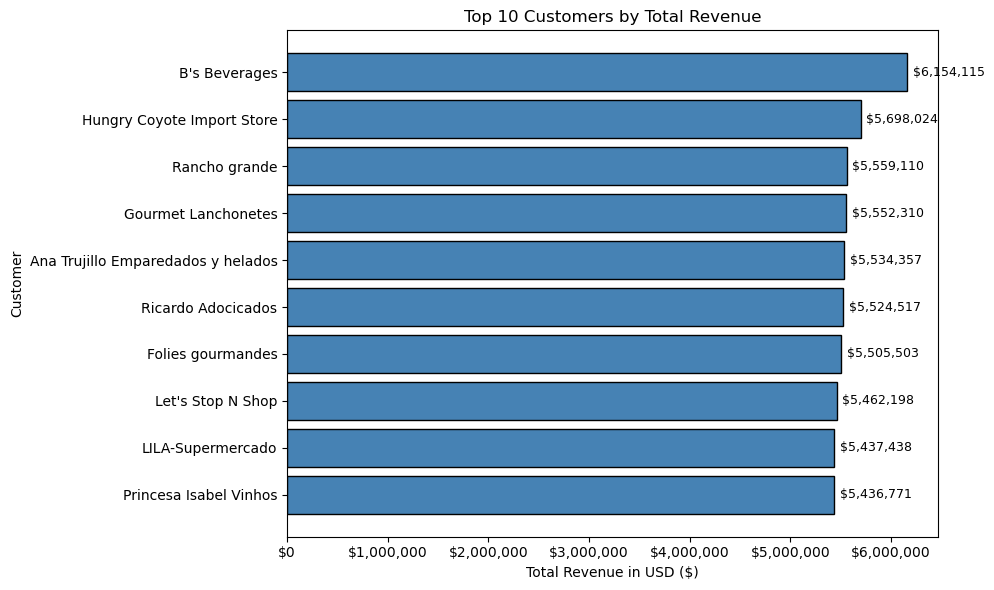

In [30]:
plt.figure(figsize=(10,6))
bars = plt.barh(top_customers['CompanyName'],
                top_customers['TotalRevenue'],
                color='steelblue',edgecolor='black')
plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Total Revenue in USD ($)')
plt.ylabel('Customer')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
             f'${int(width):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

                

In [31]:
from sklearn.linear_model import LinearRegression
import numpy as np

order_details = pd.read_sql("""
    SELECT 
        Quantity,
        ROUND(UnitPrice * Quantity * (1 - Discount), 2) AS OrderValue
    FROM [Order Details]
""", conn)

print(order_details.head())
print(order_details.describe())

   Quantity  OrderValue
0        12       168.0
1        10        98.0
2         5       174.0
3         9       167.4
4        40      1696.0
            Quantity     OrderValue
count  609283.000000  609283.000000
mean       25.503095     735.925068
std        14.453939    1069.479150
min         1.000000       2.500000
25%        13.000000     216.000000
50%        25.000000     462.000000
75%        38.000000     864.800000
max       130.000000   15810.000000


In [32]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = order_details[['Quantity']]
y = order_details['OrderValue']

model = LinearRegression()
model.fit(X, y)

print(f"R² Score: {model.score(X, y):.4f}")
print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

R² Score: 0.1520
Slope (coefficient): 28.8495
Intercept: 0.1741


C:\Users\johnn\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


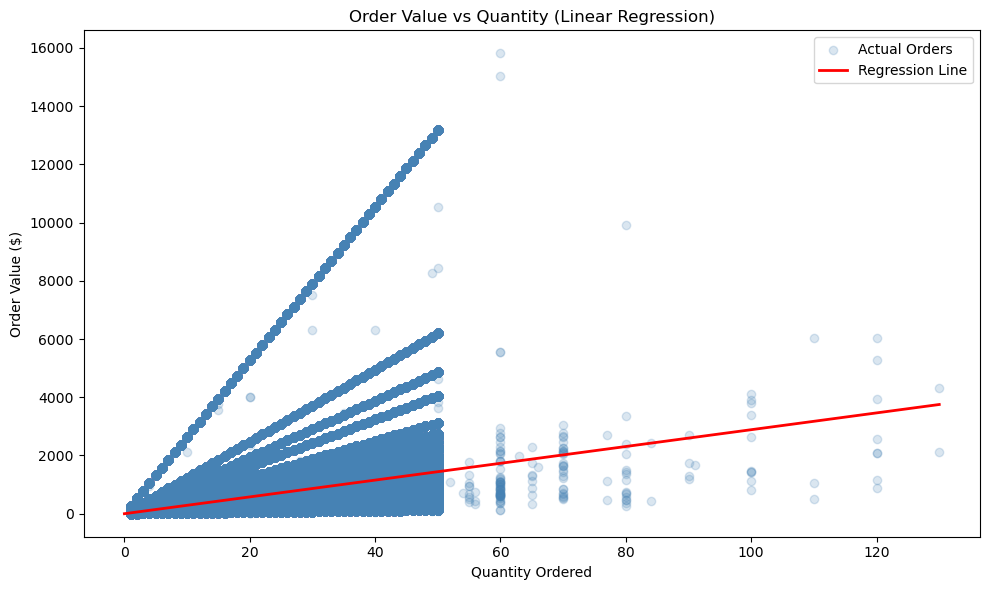

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(order_details['Quantity'], order_details['OrderValue'], 
            alpha=0.2, color='steelblue', label='Actual Orders')

x_line = np.linspace(0, 130, 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.title('Order Value vs Quantity (Linear Regression)')
plt.xlabel('Quantity Ordered')
plt.ylabel('Order Value ($)')
plt.legend()
plt.tight_layout()
plt.show()